In [12]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [13]:
df_dezembro = pd.ExcelFile(r'C:\Users\JOSEP\Documents\Projeto--An-lise-da-Desigualdade-de-Renda-e-Emprego-no-Brasil\Bronze\12-tabelas_dezembro de 2024 - Site.xlsx')
print(df_dezembro.sheet_names)

['CAGED', 'Sumário', 'Tabela 1', 'Tabela 2', 'Tabela 3', 'Tabela 4', 'Tabela 5', 'Tabela 5.1', 'Tabela 6', 'Tabela 6.1', 'Tabela 7', 'Tabela 7.1', 'Tabela 8', 'Tabela 8.1', 'Tabela 9', 'Tabela 10', 'Tabela 11']


In [14]:
df_estados = pd.read_excel(r'C:\Users\JOSEP\Documents\Projeto--An-lise-da-Desigualdade-de-Renda-e-Emprego-no-Brasil\Bronze\12-tabelas_dezembro de 2024 - Site.xlsx',sheet_name=3, skiprows=4)
df_estados


,Unnamed: 0,Região e UF,Dezembro/2024 - sem ajuste,Unnamed: 3,Unnamed: 4,Unnamed: 5,Acumulado do Ano (2024),Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,Admissões,Desligamentos,Saldos,Variação Relativa (%),Admissões,Desligamentos,Saldos,Variação Relativa (%)
1,NaN,Brasil,1524251,2059798,-535547,-1.121647,25567248,23873575,1693673,3.720946
2,NaN,Norte,73336,96629,-23293,-0.968315,1228937,1113886,115051,5.074641
3,NaN,Rondônia,9665,11965,-2300,-0.775071,167172,158028,9144,3.205014
4,NaN,Acre,3016,3751,-735,-0.661626,54523,48004,6519,6.278169
5,NaN,Amazonas,18788,23088,-4300,-0.77037,290602,253830,36772,7.111183
6,NaN,Roraima,3112,3678,-566,-0.682199,49304,43098,6206,8.144891
7,NaN,Pará,28657,40032,-11375,-1.138807,483585,444645,38940,4.105269
8,NaN,Amapá,2688,3775,-1087,-1.130666,49781,41088,8693,10.066236
9,NaN,Tocantins,7410,10340,-2930,-1.120236,133970,125193,8777,3.512978


In [15]:
df_estados.drop(df_estados.columns[0], axis=1, inplace=True,)
df_estados

,Região e UF,Dezembro/2024 - sem ajuste,Unnamed: 3,Unnamed: 4,Unnamed: 5,Acumulado do Ano (2024),Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Admissões,Desligamentos,Saldos,Variação Relativa (%),Admissões,Desligamentos,Saldos,Variação Relativa (%)
1,Brasil,1524251,2059798,-535547,-1.121647,25567248,23873575,1693673,3.720946
2,Norte,73336,96629,-23293,-0.968315,1228937,1113886,115051,5.074641
3,Rondônia,9665,11965,-2300,-0.775071,167172,158028,9144,3.205014
4,Acre,3016,3751,-735,-0.661626,54523,48004,6519,6.278169
5,Amazonas,18788,23088,-4300,-0.77037,290602,253830,36772,7.111183
6,Roraima,3112,3678,-566,-0.682199,49304,43098,6206,8.144891
7,Pará,28657,40032,-11375,-1.138807,483585,444645,38940,4.105269
8,Amapá,2688,3775,-1087,-1.130666,49781,41088,8693,10.066236
9,Tocantins,7410,10340,-2930,-1.120236,133970,125193,8777,3.512978


In [16]:
df_estados.columns = df_estados.iloc[0]
df_estados = df_estados[1:].reset_index(drop=True)
df_estados = df_estados.set_index(df_estados.columns[0])
df_estados

,Admissões,Desligamentos,Saldos,Variação Relativa (%),Admissões,Desligamentos,Saldos,Variação Relativa (%)
nan,,,,,,,,
Brasil,1524251,2059798,-535547,-1.121647,25567248,23873575,1693673,3.720946
Norte,73336,96629,-23293,-0.968315,1228937,1113886,115051,5.074641
Rondônia,9665,11965,-2300,-0.775071,167172,158028,9144,3.205014
Acre,3016,3751,-735,-0.661626,54523,48004,6519,6.278169
Amazonas,18788,23088,-4300,-0.77037,290602,253830,36772,7.111183
Roraima,3112,3678,-566,-0.682199,49304,43098,6206,8.144891
Pará,28657,40032,-11375,-1.138807,483585,444645,38940,4.105269
Amapá,2688,3775,-1087,-1.130666,49781,41088,8693,10.066236
Tocantins,7410,10340,-2930,-1.120236,133970,125193,8777,3.512978


In [17]:
# Lista das regiões exatamente como aparecem
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

# Limpa espaços do índice (se houver)
df_estados.index = df_estados.index.str.strip()

# Filtra para manter só as linhas das regiões
df_regioes = df_estados.loc[df_estados.index.isin(regioes)]

# Se quiser, reseta o índice para ficar mais limpo
df_regioes = df_regioes.reset_index()

print(df_regioes)


0           NaN Admissões Desligamentos   Saldos Variação Relativa (%)  \
0         Norte     73336         96629   -23293             -0.968315   
1      Nordeste    211183        265110   -53927             -0.673981   
2       Sudeste    790313       1073714  -283401             -1.165828   
3           Sul    296915        408101  -111186             -1.273153   
4  Centro-Oeste    150210        212396   -62186             -1.458906   

0 Admissões Desligamentos  Saldos Variação Relativa (%)  
0   1228937       1113886  115051              5.074641  
1   3462028       3131127  330901              4.344566  
2  13099045      12319875  779170              3.351787  
3   5211583       4913628  297955              3.579478  
4   2509616       2372289  137327              3.379943  


In [18]:
print(df_regioes.columns.tolist())


[nan, 'Admissões', 'Desligamentos', 'Saldos', 'Variação Relativa (%)', 'Admissões', 'Desligamentos', 'Saldos', 'Variação Relativa (%)']


In [19]:
df_regioes.columns = [
    'Região',
    'Admissões_Dezembro', 'Desligamentos_Dezembro', 'Saldos_Dezembro', 'Variação_Relativa_Dezembro',
    'Admissões_Acumulado', 'Desligamentos_Acumulado', 'Saldos_Acumulado', 'Variação_Relativa_Acumulado'
]


In [20]:
colunas_novas = [
    'Região',
    'Admissões_Dezembro', 'Desligamentos_Dezembro', 'Saldos_Dezembro', 'Variação_Relativa_Dezembro',
    'Admissões_Acumulado', 'Desligamentos_Acumulado', 'Saldos_Acumulado', 'Variação_Relativa_Acumulado'
]

df_regioes = df_regioes.reset_index(drop=True)
print(df_regioes.head())


         Região Admissões_Dezembro Desligamentos_Dezembro Saldos_Dezembro  \
0         Norte              73336                  96629          -23293   
1      Nordeste             211183                 265110          -53927   
2       Sudeste             790313                1073714         -283401   
3           Sul             296915                 408101         -111186   
4  Centro-Oeste             150210                 212396          -62186   

  Variação_Relativa_Dezembro Admissões_Acumulado Desligamentos_Acumulado  \
0                  -0.968315             1228937                 1113886   
1                  -0.673981             3462028                 3131127   
2                  -1.165828            13099045                12319875   
3                  -1.273153             5211583                 4913628   
4                  -1.458906             2509616                 2372289   

  Saldos_Acumulado Variação_Relativa_Acumulado  
0           115051             

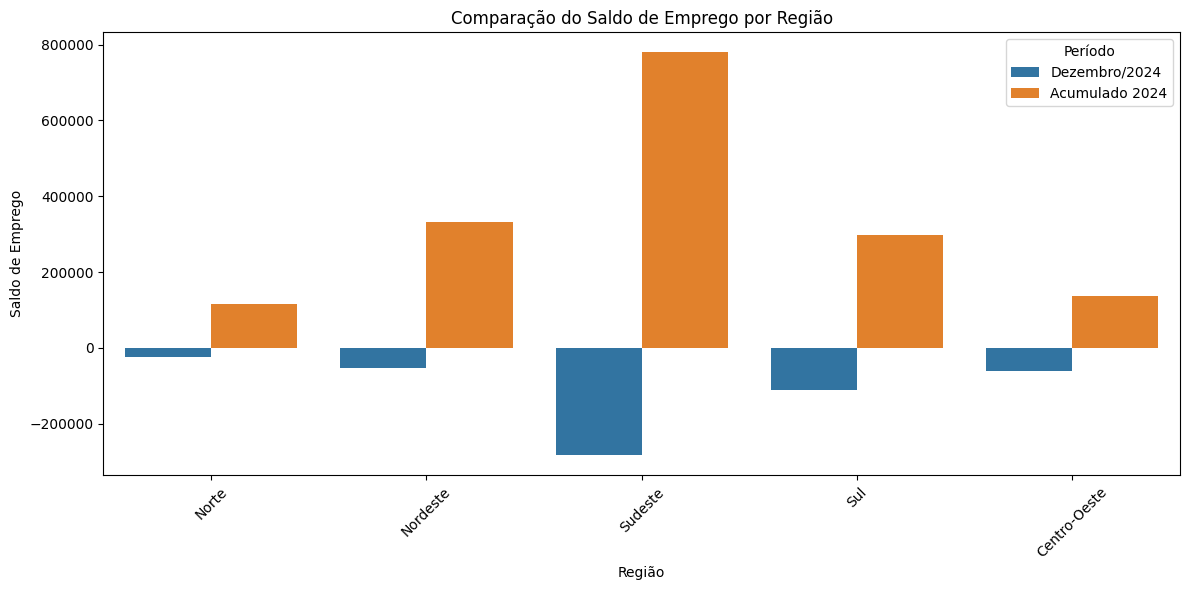

In [21]:
df_long = df_regioes.melt(
    id_vars='Região',
    value_vars=['Saldos_Dezembro', 'Saldos_Acumulado'],
    var_name='Período',
    value_name='Saldo'
)

df_long['Período'] = df_long['Período'].map({
    'Saldos_Dezembro': 'Dezembro/2024',
    'Saldos_Acumulado': 'Acumulado 2024'
})

plt.figure(figsize=(12,6))
sns.barplot(data=df_long, x='Região', y='Saldo', hue='Período')

plt.title('Comparação do Saldo de Emprego por Região')
plt.ylabel('Saldo de Emprego')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.tight_layout()
plt.show()

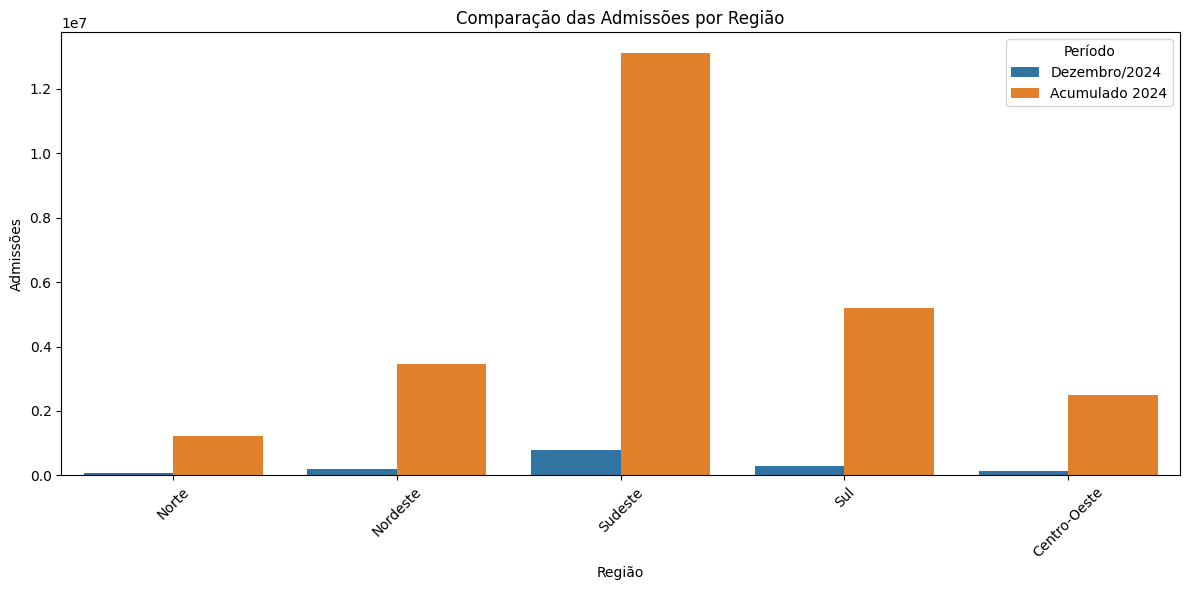

In [22]:
df_long_adm = df_regioes.melt(
    id_vars='Região',
    value_vars=['Admissões_Dezembro', 'Admissões_Acumulado'],
    var_name='Período',
    value_name='Admissões'
)

df_long_adm['Período'] = df_long_adm['Período'].map({
    'Admissões_Dezembro': 'Dezembro/2024',
    'Admissões_Acumulado': 'Acumulado 2024'
})

plt.figure(figsize=(12,6))
sns.barplot(data=df_long_adm, x='Região', y='Admissões', hue='Período')
plt.title('Comparação das Admissões por Região')
plt.ylabel('Admissões')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.tight_layout()
plt.show()


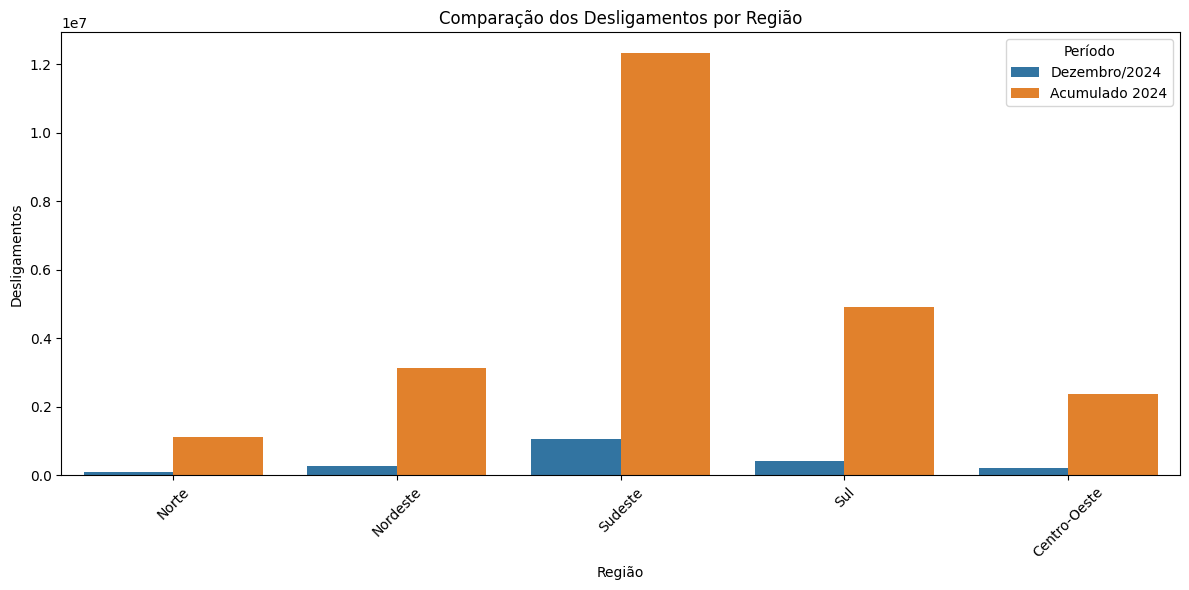

In [23]:
df_long_des = df_regioes.melt(
    id_vars='Região',
    value_vars=['Desligamentos_Dezembro', 'Desligamentos_Acumulado'],
    var_name='Período',
    value_name='Desligamentos'
)

df_long_des['Período'] = df_long_des['Período'].map({
    'Desligamentos_Dezembro': 'Dezembro/2024',
    'Desligamentos_Acumulado': 'Acumulado 2024'
})

plt.figure(figsize=(12,6))
sns.barplot(data=df_long_des, x='Região', y='Desligamentos', hue='Período')
plt.title('Comparação dos Desligamentos por Região')
plt.ylabel('Desligamentos')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.tight_layout()
plt.show()


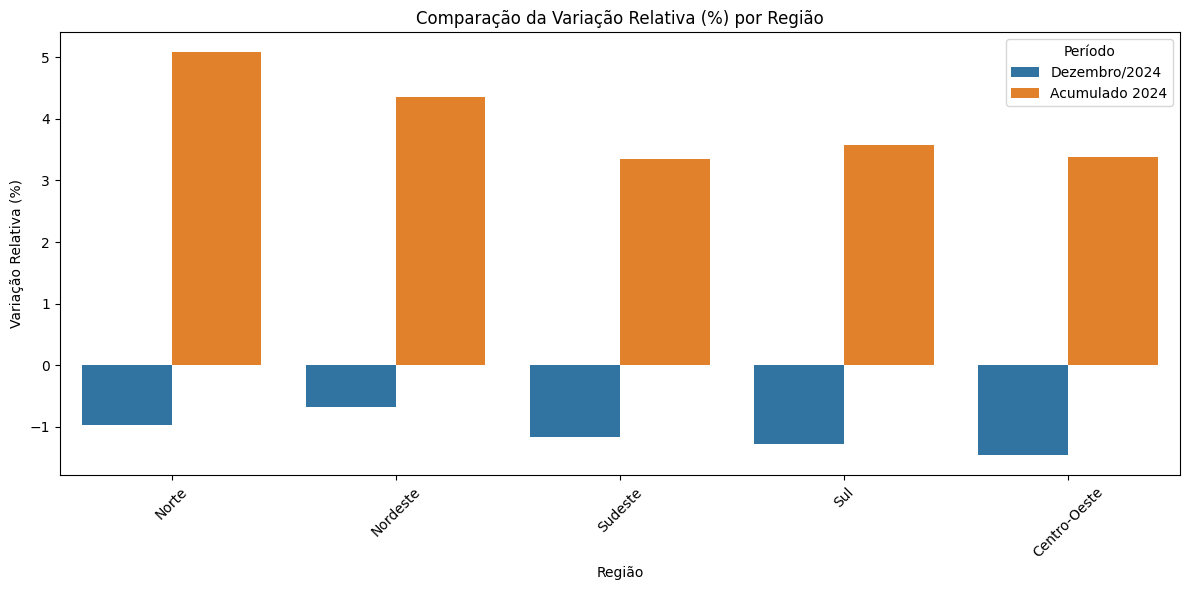

In [24]:
df_long_var = df_regioes.melt(
    id_vars='Região',
    value_vars=['Variação_Relativa_Dezembro', 'Variação_Relativa_Acumulado'],
    var_name='Período',
    value_name='Variação Relativa (%)'
)

df_long_var['Período'] = df_long_var['Período'].map({
    'Variação_Relativa_Dezembro': 'Dezembro/2024',
    'Variação_Relativa_Acumulado': 'Acumulado 2024'
})

plt.figure(figsize=(12,6))
sns.barplot(data=df_long_var, x='Região', y='Variação Relativa (%)', hue='Período')
plt.title('Comparação da Variação Relativa (%) por Região')
plt.ylabel('Variação Relativa (%)')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.legend(title='Período')
plt.tight_layout()
plt.show()


In [25]:
df_regioes.to_excel(r'C:\Users\JOSEP\Documents\Projeto--An-lise-da-Desigualdade-de-Renda-e-Emprego-no-Brasil\Ouro\Dados_Regioes.xlsx', index=False)